In [1]:
#importing os library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#changing the work directory
os.chdir('/Users/sushovanmandal/Documents/code/learn-gen-ai/analyticsVidhya genAI/Build Your First ML model/')

In [3]:
healthcare_data = pd.read_csv("Healthcare_Data_Preprocessed_FIXED.csv")
healthcare_data.head().transpose()

,0,1,2,3,4
Age,37.0,37.0,81.0,25.0,24.0
BMI,26.0,24.0,27.0,21.0,26.0
Blood_Pressure,111.0,121.0,NaN,150.0,146.0
Cholesterol,198.0,199.0,NaN,199.0,202.0
Glucose_Level,99.0,103.0,100.0,102.0,99.0
Heart_Rate,72.0,75.0,74.0,70.0,76.0
Sleep_Hours,5.5,4.5,12.1,4.3,16.0
Exercise_Hours,1.7,1.9,2.9,1.0,5.0
Water_Intake,1.6,2.6,2.6,1.7,3.4
Stress_Level,4.4,5.6,1.8,5.2,1.4


In [4]:
healthcare_data.shape

(10000, 23)

In [5]:
healthcare_data.dtypes

Age                     float64
BMI                     float64
Blood_Pressure          float64
Cholesterol             float64
Glucose_Level           float64
Heart_Rate              float64
Sleep_Hours             float64
Exercise_Hours          float64
Water_Intake            float64
Stress_Level            float64
Target                    int64
Smoking                   int64
Alcohol                   int64
Diet                      int64
MentalHealth              int64
PhysicalActivity          int64
MedicalHistory          float64
Allergies               float64
Diet_Type_Vegan            bool
Diet_Type_Vegetarian       bool
Blood_Group_AB             bool
Blood_Group_B              bool
Blood_Group_O              bool
dtype: object

In [6]:
healthcare_data.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,10000.000000,10000.000000,9471.000000,9462.000000,9486.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9465.000000,9479.000000
mean,40.228000,25.711500,130.922395,199.193934,100.154122,73.531400,8.005780,2.43173,2.477490,4.508820,0.499900,0.994500,0.992700,1.005500,0.99670,1.000600,1.001796,0.996308
std,24.350238,1.944594,27.807917,2.080687,2.205152,1.724329,4.205662,1.32928,0.634218,1.817407,0.500025,0.815681,0.816525,0.816172,0.82326,0.809979,0.813361,0.816251
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,0.00000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25.000000,24.000000,114.000000,198.000000,99.000000,72.000000,5.000000,1.50000,2.000000,3.300000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,37.000000,26.000000,135.000000,199.000000,100.000000,74.000000,6.300000,2.00000,2.400000,4.800000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
75%,49.000000,27.000000,150.000000,200.000000,102.000000,75.000000,10.800000,3.30000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,16.000000,5.00000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000


In [7]:
healthcare_data[healthcare_data['Blood_Pressure'].isna()].head().transpose()

,2,7,20,30,47
Age,81.0,65.0,63.0,81.0,24.0
BMI,27.0,28.0,24.0,26.0,26.0
Blood_Pressure,NaN,NaN,NaN,NaN,NaN
Cholesterol,NaN,202.0,NaN,202.0,199.0
Glucose_Level,100.0,99.0,96.0,96.0,99.0
Heart_Rate,74.0,73.0,72.0,73.0,74.0
Sleep_Hours,12.1,9.0,8.9,13.2,16.0
Exercise_Hours,2.9,2.2,2.6,3.6,5.0
Water_Intake,2.6,2.3,3.0,3.5,3.7
Stress_Level,1.8,3.5,5.1,2.1,3.4


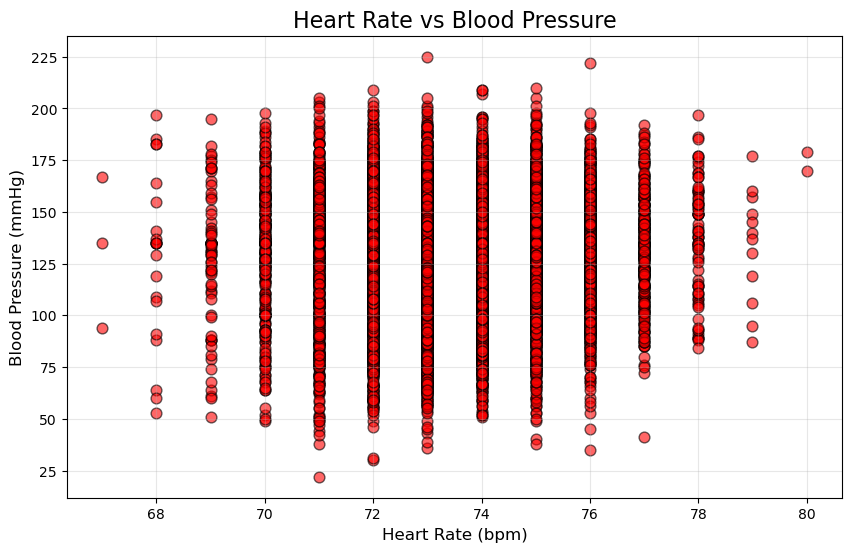

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(healthcare_data['Heart_Rate'], healthcare_data['Blood_Pressure'], alpha=0.6, color='red', edgecolors='black', s=60)

plt.title('Heart Rate vs Blood Pressure', fontsize=16)
plt.xlabel('Heart Rate (bpm)', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [9]:
healthcare_data.dropna().shape

(7783, 23)

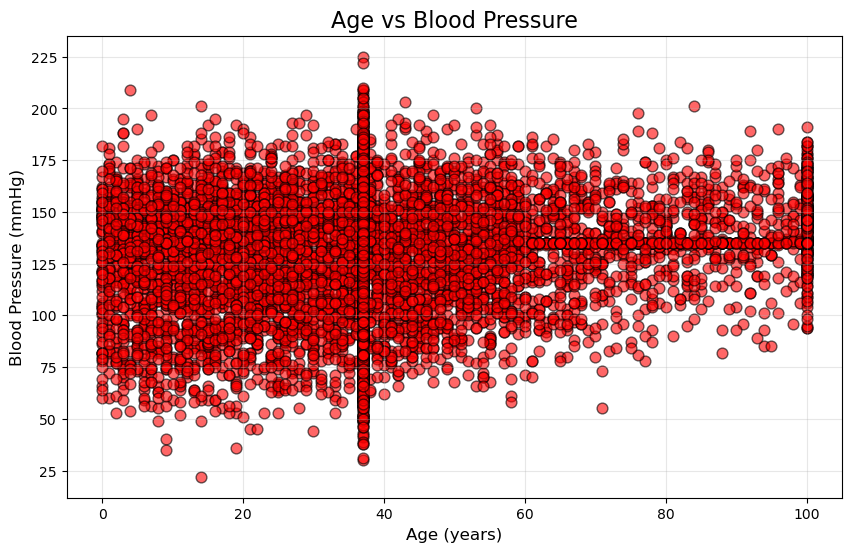

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(healthcare_data['Age'], healthcare_data['Blood_Pressure'], alpha=0.6, color='red', edgecolors='black', s=60)

plt.title('Age vs Blood Pressure', fontsize=16)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Blood Pressure (mmHg)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

# Impute missing blood pressure, cholesterol and glucose level

In [11]:
# Step 1: Define age bins and labels
bins = [0, 60, 80, 101]        # lower bounds: <60, 60–80, 80–100
labels = ['<60', '60-80', '80-100']
healthcare_data['age_group'] = pd.cut(healthcare_data['Age'], bins=bins, labels=labels, include_lowest=True, right=False)

In [12]:
healthcare_data['age_group'].value_counts()

age_group
<60       8146
80-100     969
60-80      885
Name: count, dtype: int64

In [13]:
healthcare_data.isnull().sum()

Age                       0
BMI                       0
Blood_Pressure          529
Cholesterol             538
Glucose_Level           514
Heart_Rate                0
Sleep_Hours               0
Exercise_Hours            0
Water_Intake              0
Stress_Level              0
Target                    0
Smoking                   0
Alcohol                   0
Diet                      0
MentalHealth              0
PhysicalActivity          0
MedicalHistory          535
Allergies               521
Diet_Type_Vegan           0
Diet_Type_Vegetarian      0
Blood_Group_AB            0
Blood_Group_B             0
Blood_Group_O             0
age_group                 0
dtype: int64

In [14]:
# Step 2: Compute median blood_pressure for each age group (only from non-missing values)
median_by_age = healthcare_data.groupby('age_group')['Blood_Pressure'].median()

print("Median Blood Pressure by Age Group:")
print(median_by_age)

Median Blood Pressure by Age Group:
age_group
<60       133.0
60-80     135.0
80-100    135.0
Name: Blood_Pressure, dtype: float64


/var/folders/1j/dspwry7j3t1c2fy51tk2qz3c0000gn/T/ipykernel_24302/1062098515.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_by_age = healthcare_data.groupby('age_group')['Blood_Pressure'].median()


We can just impute age group median as the blood pressure for all missing values.

In [15]:
columns_to_fill_with_median = ['Blood_Pressure', 'Cholesterol', 'Glucose_Level']

In [16]:
#compute the median for each column within each age group and fill NA values with that median
for col in columns_to_fill_with_median:
    healthcare_data[col] = healthcare_data.groupby('age_group')[col].transform(lambda x: x.fillna(x.median()))

/var/folders/1j/dspwry7j3t1c2fy51tk2qz3c0000gn/T/ipykernel_24302/1917339775.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  healthcare_data[col] = healthcare_data.groupby('age_group')[col].transform(lambda x: x.fillna(x.median()))


In [17]:
healthcare_data = healthcare_data.drop(columns=['age_group'])

In [18]:
healthcare_data.isnull().sum()

Age                       0
BMI                       0
Blood_Pressure            0
Cholesterol               0
Glucose_Level             0
Heart_Rate                0
Sleep_Hours               0
Exercise_Hours            0
Water_Intake              0
Stress_Level              0
Target                    0
Smoking                   0
Alcohol                   0
Diet                      0
MentalHealth              0
PhysicalActivity          0
MedicalHistory          535
Allergies               521
Diet_Type_Vegan           0
Diet_Type_Vegetarian      0
Blood_Group_AB            0
Blood_Group_B             0
Blood_Group_O             0
dtype: int64

# Treating missing MedicalHistory and Allergies

Let's remove rows from which MedicalHistory is Nan and remove Allergies Column

In [19]:
healthcare_data['Allergies'].corr(healthcare_data['Target'])

np.float64(-0.013025586667613036)

Negligible correlation

In [20]:
hdf = healthcare_data.drop(columns=['Allergies'])

In [21]:
hdf = hdf.dropna()

In [22]:
hdf.shape

(9465, 22)

# Convert BMI to categorical

In [23]:
# Step 1: Define bmi bins and labels, since min BMI is 19, we don't have to deal with underweight
bins = [0, 25, 30, 100]        # lower bounds: <25, 25–29.9, 30–100
labels = [0, 1, 2]
hdf['bmi_cat'] = pd.cut(hdf['BMI'], bins=bins, labels=labels, include_lowest=True, right=False)

In [24]:
hdf.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,bmi_cat
0,37.0,26.0,111.0,198.0,99.0,72.0,5.5,1.7,1.6,4.4,...,1,2,1,0.0,False,True,True,False,False,1
1,37.0,24.0,121.0,199.0,103.0,75.0,4.5,1.9,2.6,5.6,...,1,2,1,2.0,False,False,True,False,False,0
2,81.0,27.0,135.0,202.0,100.0,74.0,12.1,2.9,2.6,1.8,...,2,0,0,1.0,True,False,False,False,False,1
3,25.0,21.0,150.0,199.0,102.0,70.0,4.3,1.0,1.7,5.2,...,1,2,1,2.0,True,False,False,True,False,0
4,24.0,26.0,146.0,202.0,99.0,76.0,16.0,5.0,3.4,1.4,...,2,0,2,0.0,False,True,False,True,False,1


In [25]:
hdf.isnull().sum()

Age                     0
BMI                     0
Blood_Pressure          0
Cholesterol             0
Glucose_Level           0
Heart_Rate              0
Sleep_Hours             0
Exercise_Hours          0
Water_Intake            0
Stress_Level            0
Target                  0
Smoking                 0
Alcohol                 0
Diet                    0
MentalHealth            0
PhysicalActivity        0
MedicalHistory          0
Diet_Type_Vegan         0
Diet_Type_Vegetarian    0
Blood_Group_AB          0
Blood_Group_B           0
Blood_Group_O           0
bmi_cat                 0
dtype: int64

In [26]:
hdf = hdf.drop(columns=['BMI'])

In [27]:
hdf.head()

,Age,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,bmi_cat
0,37.0,111.0,198.0,99.0,72.0,5.5,1.7,1.6,4.4,1,...,1,2,1,0.0,False,True,True,False,False,1
1,37.0,121.0,199.0,103.0,75.0,4.5,1.9,2.6,5.6,1,...,1,2,1,2.0,False,False,True,False,False,0
2,81.0,135.0,202.0,100.0,74.0,12.1,2.9,2.6,1.8,0,...,2,0,0,1.0,True,False,False,False,False,1
3,25.0,150.0,199.0,102.0,70.0,4.3,1.0,1.7,5.2,0,...,1,2,1,2.0,True,False,False,True,False,0
4,24.0,146.0,202.0,99.0,76.0,16.0,5.0,3.4,1.4,0,...,2,0,2,0.0,False,True,False,True,False,1


# Convert Cholesterol to categorical

In [28]:
hdf.loc[hdf['Cholesterol'] < 200, 'chol_cat'] = 0

In [29]:
hdf.loc[hdf['Cholesterol'] >= 200, 'chol_cat'] = 1

In [30]:
hdf = hdf.drop(columns=['Cholesterol'])

In [31]:
hdf.head()

,Age,Blood_Pressure,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,...,MentalHealth,PhysicalActivity,MedicalHistory,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,bmi_cat,chol_cat
0,37.0,111.0,99.0,72.0,5.5,1.7,1.6,4.4,1,2,...,2,1,0.0,False,True,True,False,False,1,0.0
1,37.0,121.0,103.0,75.0,4.5,1.9,2.6,5.6,1,0,...,2,1,2.0,False,False,True,False,False,0,0.0
2,81.0,135.0,100.0,74.0,12.1,2.9,2.6,1.8,0,2,...,0,0,1.0,True,False,False,False,False,1,1.0
3,25.0,150.0,102.0,70.0,4.3,1.0,1.7,5.2,0,2,...,2,1,2.0,True,False,False,True,False,0,0.0
4,24.0,146.0,99.0,76.0,16.0,5.0,3.4,1.4,0,0,...,0,2,0.0,False,True,False,True,False,1,1.0


In [32]:
hdf.describe()

,Age,Blood_Pressure,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,chol_cat
count,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000
mean,39.319070,130.922345,100.159324,73.544638,7.916334,2.403603,2.468917,4.543803,0.506075,0.995034,0.990914,1.004015,0.992921,1.001057,1.001796,0.407713
std,23.712066,27.196325,2.172305,1.721691,4.189701,1.323669,0.632809,1.811680,0.499990,0.814905,0.816230,0.815494,0.822119,0.809391,0.813361,0.491435
min,0.000000,22.000000,93.000000,67.000000,0.000000,0.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,115.000000,99.000000,72.000000,5.000000,1.500000,2.000000,3.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,135.000000,100.000000,74.000000,6.200000,2.000000,2.400000,4.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
75%,47.000000,149.000000,102.000000,75.000000,10.600000,3.200000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000
max,100.000000,225.000000,107.000000,80.000000,16.000000,5.000000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000


# Convert Glucose to categorical

In [33]:
hdf.loc[hdf['Glucose_Level'] < 100, 'gluco_cat'] = 0

In [34]:
hdf.loc[hdf['Glucose_Level'] >= 100, 'gluco_cat'] = 1

In [35]:
hdf.head()

,Age,Blood_Pressure,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,...,PhysicalActivity,MedicalHistory,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,bmi_cat,chol_cat,gluco_cat
0,37.0,111.0,99.0,72.0,5.5,1.7,1.6,4.4,1,2,...,1,0.0,False,True,True,False,False,1,0.0,0.0
1,37.0,121.0,103.0,75.0,4.5,1.9,2.6,5.6,1,0,...,1,2.0,False,False,True,False,False,0,0.0,1.0
2,81.0,135.0,100.0,74.0,12.1,2.9,2.6,1.8,0,2,...,0,1.0,True,False,False,False,False,1,1.0,1.0
3,25.0,150.0,102.0,70.0,4.3,1.0,1.7,5.2,0,2,...,1,2.0,True,False,False,True,False,0,0.0,1.0
4,24.0,146.0,99.0,76.0,16.0,5.0,3.4,1.4,0,0,...,2,0.0,False,True,False,True,False,1,1.0,0.0


In [36]:
hdf = hdf.drop(columns=['Glucose_Level'])

In [37]:
hdf.describe()

,Age,Blood_Pressure,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,chol_cat,gluco_cat
count,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000,9465.000000
mean,39.319070,130.922345,73.544638,7.916334,2.403603,2.468917,4.543803,0.506075,0.995034,0.990914,1.004015,0.992921,1.001057,1.001796,0.407713,0.631484
std,23.712066,27.196325,1.721691,4.189701,1.323669,0.632809,1.811680,0.499990,0.814905,0.816230,0.815494,0.822119,0.809391,0.813361,0.491435,0.482428
min,0.000000,22.000000,67.000000,0.000000,0.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,115.000000,72.000000,5.000000,1.500000,2.000000,3.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,37.000000,135.000000,74.000000,6.200000,2.000000,2.400000,4.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
75%,47.000000,149.000000,75.000000,10.600000,3.200000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000
max,100.000000,225.000000,80.000000,16.000000,5.000000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000


# shuffle dataset

In [38]:
hdf_final = hdf.sample(frac = 1, random_state=1)

In [39]:
hdf_final.head()

,Age,Blood_Pressure,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,...,PhysicalActivity,MedicalHistory,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,bmi_cat,chol_cat,gluco_cat
7876,53.0,113.0,74.0,7.3,2.2,2.8,4.4,0,1,2,...,1,1.0,False,True,True,False,False,0,1.0,1.0
5639,61.0,140.0,73.0,9.2,2.6,2.8,4.2,0,0,2,...,1,1.0,False,True,False,False,True,1,1.0,1.0
6983,45.0,90.0,70.0,5.5,2.6,1.8,6.9,0,2,2,...,1,1.0,True,False,True,False,False,1,1.0,1.0
7393,20.0,82.0,71.0,16.0,5.0,4.0,0.4,1,0,2,...,2,2.0,False,True,False,True,False,1,0.0,0.0
4408,22.0,153.0,73.0,16.0,5.0,4.2,2.4,0,1,0,...,0,2.0,True,False,True,False,False,1,0.0,1.0


In [40]:
hdf.shape, hdf_final.shape

((9465, 22), (9465, 22))

# Prepare Data

In [41]:
#Separating the independent and target variables
y = hdf_final['Target']
X = hdf_final.drop(columns = ['Target'], axis = 1)

In [42]:
X.head().transpose()

,7876,5639,6983,7393,4408
Age,53.0,61.0,45.0,20.0,22.0
Blood_Pressure,113.0,140.0,90.0,82.0,153.0
Heart_Rate,74.0,73.0,70.0,71.0,73.0
Sleep_Hours,7.3,9.2,5.5,16.0,16.0
Exercise_Hours,2.2,2.6,2.6,5.0,5.0
Water_Intake,2.8,2.8,1.8,4.0,4.2
Stress_Level,4.4,4.2,6.9,0.4,2.4
Smoking,1,0,2,0,1
Alcohol,2,2,2,2,0
Diet,0,0,2,2,0


# Cross validation for k selection of KNN Classifier

In [43]:
#import libraries
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
#from sklearn.metrics import f1_score

In [44]:
#define cross-validation method to use
kf = KFold(n_splits=10, random_state=42, shuffle=True)

In [58]:
#for loop to get accuracy scores for train and test for k values ranging from 1 to 51
train_mean_score = []
train_score_std = []
test_mean_score = []
test_score_std = []
for n in range(1,51):
    
    knn_model = KNeighborsClassifier(n)
    pipeline = make_pipeline(StandardScaler(), knn_model)
    cross_validate_results = cross_validate(pipeline, X, y, cv=kf, scoring='f1', return_train_score=True)

    test_scores = cross_validate_results['test_score']
    test_mean_score.append(test_scores.mean())
    test_score_std.append(test_scores.std())

    train_scores = cross_validate_results['train_score']
    train_mean_score.append(train_scores.mean())
    train_score_std.append(train_scores.std())

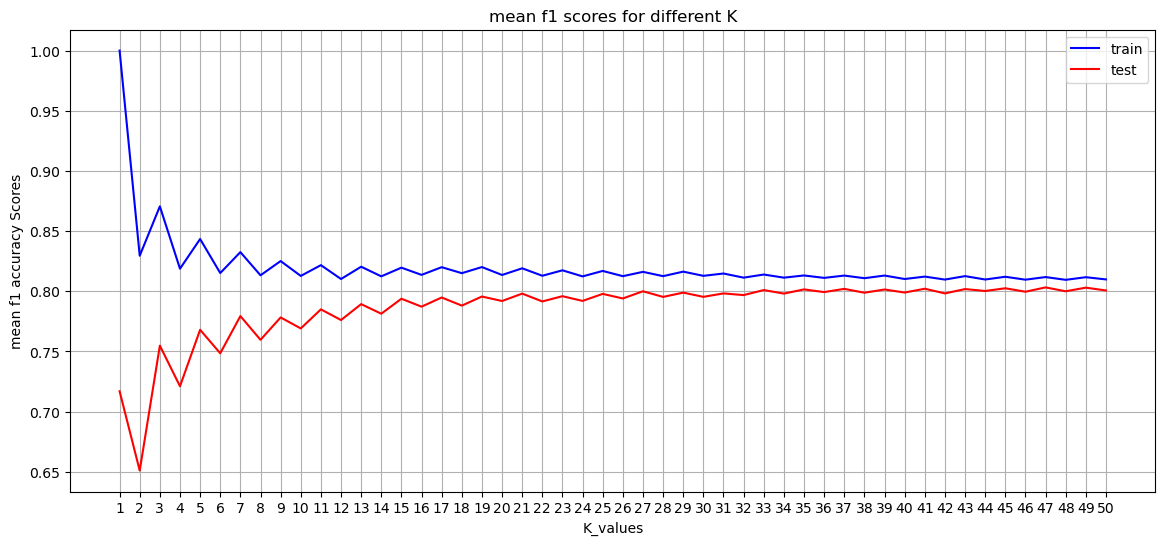

In [60]:
#plot the accuracy scores
plt.figure(figsize = (14,6))
plt.title('mean f1 scores for different K')
plt.plot(np.arange(1, len(train_mean_score)+1), train_mean_score, color = 'blue', label = 'train')
plt.plot(np.arange(1, len(train_mean_score)+1), test_mean_score, color = 'red', label = 'test')
plt.xticks(np.arange(1, len(train_mean_score)+1))
plt.xlabel('K_values')
plt.ylabel('mean f1 accuracy Scores')
plt.legend()
plt.grid()
plt.show()

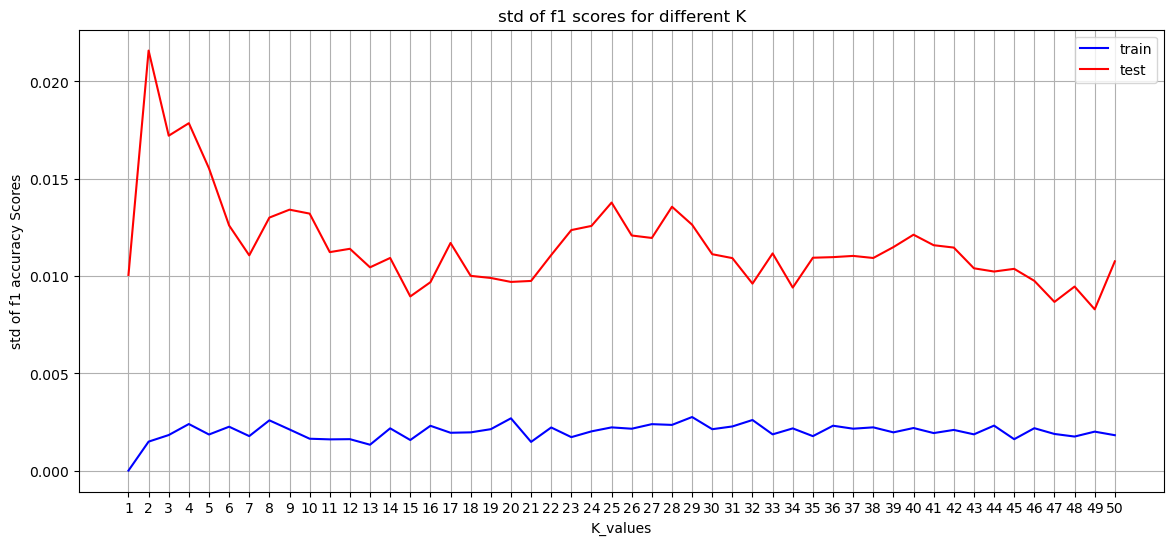

In [61]:
#plot the std for accuracy scores
plt.figure(figsize = (14,6))
plt.title('std of f1 scores for different K')
plt.plot(np.arange(1, len(train_mean_score)+1), train_score_std, color = 'blue', label = 'train')
plt.plot(np.arange(1, len(train_mean_score)+1), test_score_std, color = 'red', label = 'test')
plt.xticks(np.arange(1, len(train_mean_score)+1))
plt.xlabel('K_values')
plt.ylabel('std of f1 accuracy Scores')
plt.legend()
plt.grid()
plt.show()

Accordingly let's select n=49 neighbors for KNN classifier for this problem as it's giving highest accuracy and stable test and train scores with minimum difference

# Final selected KNN Classifier model

In [62]:
knn_model = KNeighborsClassifier(49)
pipeline = make_pipeline(StandardScaler(), knn_model)
cross_validate_results = cross_validate(pipeline, X, y, cv=kf, scoring='f1', return_train_score=True)

In [63]:
test_scores = cross_validate_results['test_score']
print("Cross-validation scores:", test_scores)
print("Cross-validation Mean score:", test_scores.mean())
print("Cross-validation STD:", test_scores.std())

Cross-validation scores: [0.8008342  0.80286006 0.80572597 0.81458967 0.79637097 0.80585366
 0.81309398 0.8064843  0.78389831 0.8       ]
Cross-validation Mean score: 0.8029711108806596
Cross-validation STD: 0.008285192458741429


In [64]:
train_scores = cross_validate_results['train_score']
print("Cross-validation train scores:", train_scores)
print("Cross-validation train Mean score:", train_scores.mean())
print("Cross-validation train STD:", train_scores.std())

Cross-validation train scores: [0.81383705 0.8111073  0.81125601 0.80736252 0.81334247 0.81155085
 0.80941499 0.81408644 0.81324684 0.81139355]
Cross-validation train Mean score: 0.8116598032245432
Cross-validation train STD: 0.002000897137686065


Our final KNN classifier model for the problem gives mean train f1 score of 81.16% and mean test score of 80.3%

## Confusion Matrix and Accuracy Score for the chosen 49 model

In [65]:
X.shape, y.shape

((9465, 21), (9465,))

In [66]:
#import train test split
from sklearn.model_selection import train_test_split

In [67]:
#split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [68]:
#A quick look at the shape of the datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6625, 21), (2840, 21), (6625,), (2840,))

In [69]:
#create an instance for StandardScaler
scaler = StandardScaler()

In [70]:
#let's transform the train data
X_train_scaled = scaler.fit_transform(X_train)

In [71]:
X_train_scaled

array([[-0.09203252,  1.0606589 , -0.31690543, ..., -1.64078081,
        -0.83017419,  0.76679032],
       [-0.98541967, -0.00948578, -1.48654244, ...,  0.52891437,
        -0.83017419, -1.30413748],
       [-0.09203252, -0.26779657, -0.90172393, ...,  0.52891437,
        -0.83017419,  0.76679032],
       ...,
       [ 1.60965728, -0.59991044, -0.90172393, ..., -1.64078081,
         1.20456647,  0.76679032],
       [-0.09203252, -1.96526745, -0.31690543, ...,  0.52891437,
        -0.83017419, -1.30413748],
       [-0.09203252,  1.13446198,  0.26791308, ..., -1.64078081,
        -0.83017419,  0.76679032]], shape=(6625, 21))

In [72]:
X_test_scaled = scaler.transform(X_test)

In [73]:
X_test_scaled.shape

(2840, 21)

In [74]:
knn_model = KNeighborsClassifier(49)

In [75]:
knn_model.fit(X_train_scaled, y_train)

,n_neighbors,49
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [76]:
#making predictions on the same training data
y_train_pred = knn_model.predict(X_train_scaled)

In [77]:
#making predictions on the test data based on the learniing from fitting model on the train data
y_pred = knn_model.predict(X_test_scaled)

In [78]:
#import confusion matrix
from sklearn.metrics import confusion_matrix, accuracy_score

In [79]:
# Generate the confusion matrix for train data
train_cm = confusion_matrix(y_train, y_train_pred)

print("Confusion Matrix for Train Set:")
print(train_cm)

Confusion Matrix for Train Set:
[[2565  685]
 [ 611 2764]]


In our case, when we create the confusion matrix for train data - 
- True Negative is 2565
- False Positive is 685
- False Negative is 611 and 
- True Positive is 2764

In [81]:
# Generate the confusion matrix for test data
test_cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix for Test Set:")
print(test_cm)


Confusion Matrix for Test Set:
[[1101  324]
 [ 242 1173]]


In [82]:
accuracy_score(y_train, y_train_pred)

0.804377358490566

In [83]:
accuracy_score(y_test, y_pred)

0.8007042253521127

In [84]:
#calculating precision on train set
from sklearn.metrics import precision_score
train_precision = precision_score(y_train, y_train_pred)
print(train_precision)

0.8013917077413744


In [85]:
#calculating precision on test set
test_precision = precision_score(y_test, y_pred)
print(test_precision)

0.7835671342685371


In [86]:
#calculating recall on train set
from sklearn.metrics import recall_score
train_recall = recall_score(y_train, y_train_pred)
print(train_recall)

0.818962962962963


In [87]:
#calculating recall on test set
test_recall = recall_score(y_test, y_pred)
print(test_recall)

0.8289752650176678


In [88]:
#calculating f1_score on train set
from sklearn.metrics import f1_score
train_f1 = f1_score(y_train, y_train_pred)
print(train_f1)

0.8100820633059789


In [89]:
#calculating precision on test set
test_f1 = f1_score(y_test, y_pred)
print(test_f1)

0.8056318681318682


In [90]:
#create classification for train set
from sklearn.metrics import classification_report
train_classification_report = classification_report(y_train, y_train_pred)
print(train_classification_report)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3250
           1       0.80      0.82      0.81      3375

    accuracy                           0.80      6625
   macro avg       0.80      0.80      0.80      6625
weighted avg       0.80      0.80      0.80      6625



In [91]:
#create classification for test set
from sklearn.metrics import classification_report
test_classification_report = classification_report(y_test, y_pred)
print(test_classification_report)

              precision    recall  f1-score   support

           0       0.82      0.77      0.80      1425
           1       0.78      0.83      0.81      1415

    accuracy                           0.80      2840
   macro avg       0.80      0.80      0.80      2840
weighted avg       0.80      0.80      0.80      2840



# Try out XGBoost Classifier

In [92]:
from xgboost import XGBClassifier

In [93]:
X.shape, y.shape

((9465, 21), (9465,))

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [96]:
X_train.shape, X_test.shape

((7572, 21), (1893, 21))

In [97]:
xgb = XGBClassifier(
    n_estimators=500,               # many trees
    max_depth=6,                    # moderate depth
    learning_rate=0.05,             # small eta
    subsample=0.8,                  # row sampling
    colsample_bytree=0.8,           # column sampling
    random_state=42,
    eval_metric='logloss',          # or 'auc'
    tree_method='hist',             # fast histogram (default now)
    enable_categorical=True,       # set True if you have categorical features
    early_stopping_rounds=50,       # important!
    n_jobs=-1
)

In [98]:
# Train with early stopping
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.66988
[50]	validation_0-logloss:0.38255
[100]	validation_0-logloss:0.35697
[150]	validation_0-logloss:0.35202
[200]	validation_0-logloss:0.34942
[250]	validation_0-logloss:0.34891
[295]	validation_0-logloss:0.34980


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,'logloss'


In [99]:
# Predictions
y_pred = xgb.predict(X_test)
y_pred_proba = xgb.predict_proba(X_test)[:, 1]

In [100]:
from sklearn.metrics import roc_auc_score

In [101]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.8473322768092975
AUC: 0.9243845801748294
              precision    recall  f1-score   support

           0       0.85      0.84      0.84       935
           1       0.84      0.86      0.85       958

    accuracy                           0.85      1893
   macro avg       0.85      0.85      0.85      1893
weighted avg       0.85      0.85      0.85      1893

